In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [4]:
df = pd.read_csv("../../dataset/Cleaned_Suicide_Detection_ML.csv")
df.shape

(231988, 4)

In [5]:
X = df["clean_text"]
y = df["labels"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
tfidf = TfidfVectorizer(max_features=7000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [8]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [9]:
y_pred = model.predict(X_test_tfidf)

In [10]:
print(accuracy_score(y_test, y_pred))

0.9075606707185655


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.87      0.90     23078
           1       0.88      0.95      0.91     23320

    accuracy                           0.91     46398
   macro avg       0.91      0.91      0.91     46398
weighted avg       0.91      0.91      0.91     46398



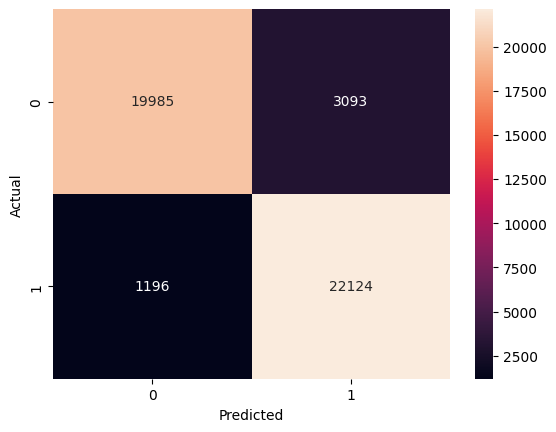

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
sample = ["I don't want to die"]
sample_tfidf = tfidf.transform(sample)
prediction = model.predict(sample_tfidf)
prediction

array([1])

In [14]:
joblib.dump(model, "../../models/nb_model.pkl")
joblib.dump(tfidf, "../../models/tfidf_vectorizer.pkl")

['../../models/tfidf_vectorizer.pkl']